In [49]:
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
from operators import productN
import numpy as np
#from helps_and_enhancers import *
import matplotlib.pyplot as plt
from ANFIS import ANFIS
import time
import copy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

<H1>Przygotowanie zbioru danych: XOR<H1>

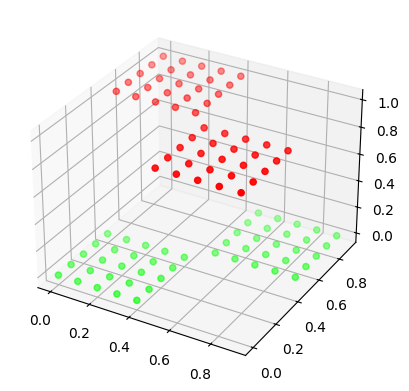

In [50]:
x = np.arange(0, 1, 0.1)
x,y = np.meshgrid(x, x)

dataX = x.flatten()
dataY = y.flatten()
dataXY1 = np.column_stack((dataX,dataY,np.ones(len(dataX))))
dataXY = np.column_stack((dataX,dataY))

data_labels = np.logical_xor(dataX >= 0.5, dataY >= 0.5) 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

rgb = [[1,0,0] if cc else [0,1,0] for cc in data_labels]

ax.scatter(dataX, dataY, data_labels, c=rgb)

plt.show()

<H1>Utworzenie funkcji przynależności</H1>

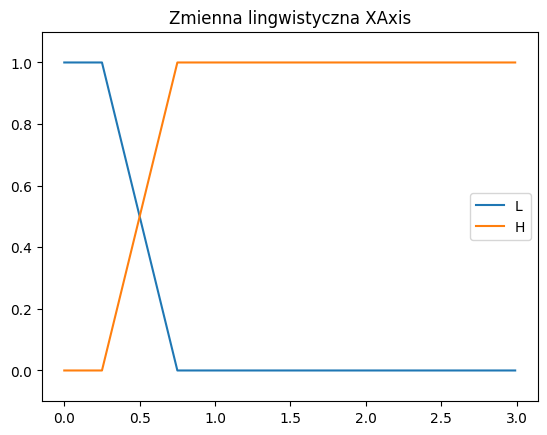

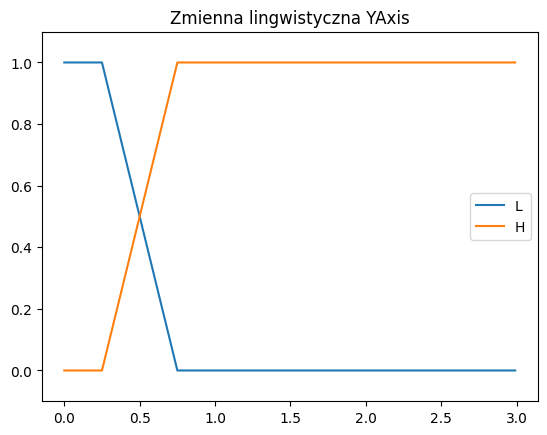

In [51]:
varX = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "XAxis", ["L","H"]) # low, high
varY = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "YAxis", ["L","H"])

#mf1 = [[-0.5, 0.25, 0.25, 0.25], [0.5, 0.25, 0.1, 0.1]]
#varX = FuzzyInputVariable_List_Trapezoids(mf1, "XAxis", ["L","H"])
#varY = FuzzyInputVariable_List_Trapezoids(mf1, "YAxis", ["L","H"])

#Wyświetlanie funkcji przynależnosci
plt.figure()
varX.show()
plt.legend()

plt.figure()
varY.show()
plt.legend()

plt.show()

<H1>Inicjalizacja systemu ANFIS</H1>

Parametry początkowe:
Przesłanki:  [[0.5, 0.5], [0.5, 0.5]] 
Konkluzje:  [[0.66985669 0.13631386 0.1973486 ]
 [0.73775093 0.40121995 0.37094685]
 [0.83996147 0.01921739 0.19094728]
 [0.27783202 0.6902448  0.00769175]]


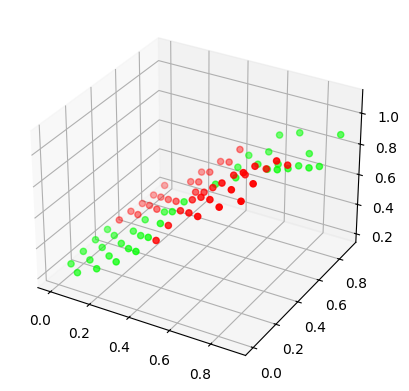

In [52]:
X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=25)

fis = ANFIS([varX, varY], X_train.T, y_train)

print("Parametry początkowe:\nPrzesłanki: ",fis.premises, "\nKonkluzje: ", fis.tsk)

fis.show_results()

<H1>Uczenie systemu ANFIS</H1>

Optymalizacja zakończona!
z blędem:   3.1218085290601866e-06
Liczba ew:  32243
Liczba it:  50
TIME elapsed:  3.3340868949890137


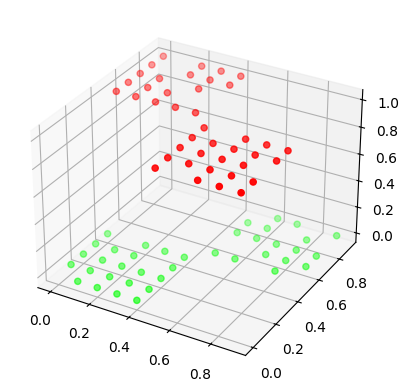

In [53]:
start = time.time()
fis.train(True, True, False, True, n_iter=50)
end = time.time()
print("TIME elapsed: ", end - start)   
fis.training_data = X_train.T
fis.expected_labels = y_train
fis.show_results()

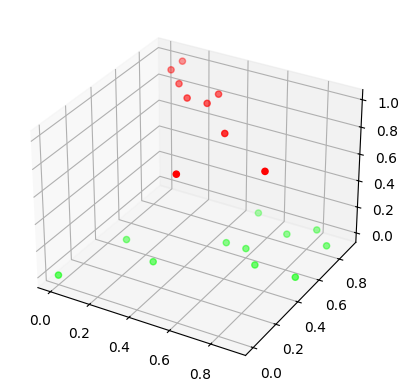

[[11  0]
 [ 0  9]]


In [54]:
fis.training_data = X_test.T
fis.expected_labels = y_test
fis.show_results()

y_pred = fis.anfis_estimate_labels(fis.premises,fis.op,fis.tsk)
y_pred = list(map(round,y_pred.flatten()))
print(confusion_matrix(y_test, y_pred))

<H1>Sprawdzanie parametrów jakich nauczył się system</H1>

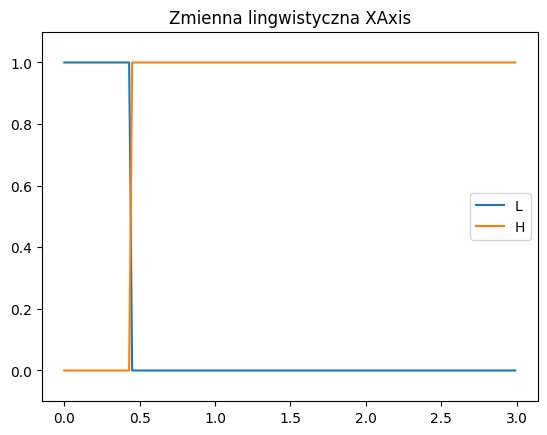

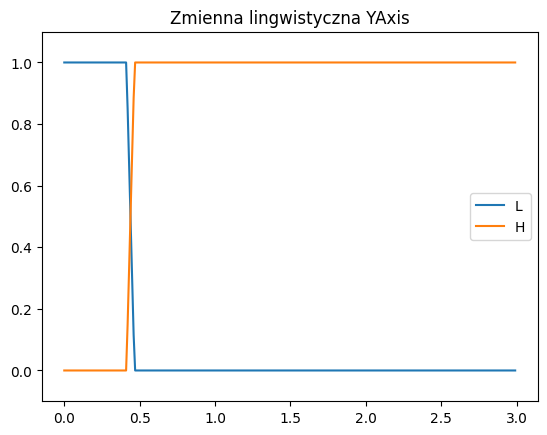

In [55]:
#Wyświetlanie funkcji przynależnosci
plt.figure()
varX.show()
plt.legend()

plt.figure()
varY.show()
plt.legend()

plt.show()

In [56]:
print("Parametry końcowe:\nPrzesłanki: ", repr(fis.premises), "\nKonkluzje: ", repr(fis.tsk))

Parametry końcowe:
Przesłanki:  array([[0.4404418 , 0.01159646],
       [0.4391105 , 0.05433986]]) 
Konkluzje:  array([[7.79371927e-13, 1.32371972e-12, 2.98800433e-12],
       [3.22218836e-16, 9.00442214e-16, 9.99999911e-01],
       [6.44774943e-16, 4.40091119e-07, 9.99999674e-01],
       [1.33927859e-12, 1.33345564e-12, 1.91963265e-12]])


#### Zapisanie nauczonych parametrów do zmiennych

In [57]:
learned_premises = fis.premises.copy()
learned_tsk = fis.tsk.copy()

<H1>Sprawdzanie wpływu parametrów na wyniki systemu</H1>

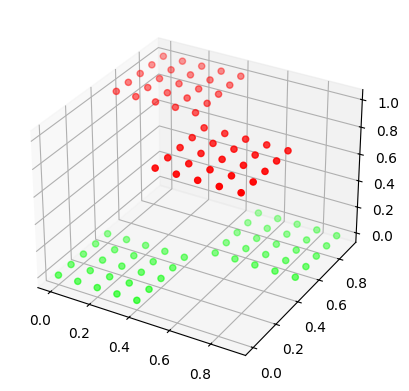

In [58]:
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

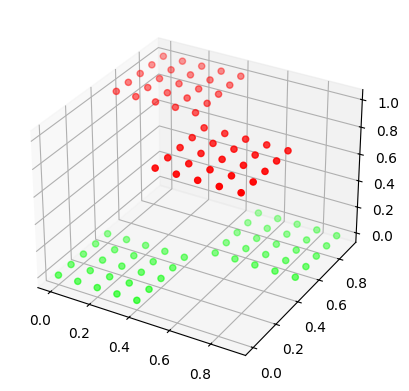

In [59]:
fis.premises = learned_premises
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

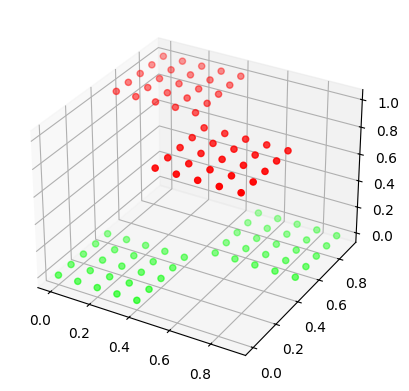

In [60]:
fis.tsk = learned_tsk
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

<H1>Zadanie</H1>

Naucz system ANFIS tabliczki mnożenia. Zacznij od rozmiaru 2x2 i zwiększaj w obu kierunkach z krokiem 1 (kolejno 2x2, 3x3, 4x4, 5x5). Mierz czas jaki jest potrzebny na nauczenie systemu w zależności od wymiarów tabliczki. Zrób wykres wymiaru tabliczki od czasu uczenia i wyślij wraz ze swoim komentarzem na maila iperenc@kis.p.lodz.pl. Nie musisz dojść do rozmiaru 10x10, wystarczy 5x5, ważne żeby było widać jaka jest zależność.

Tabliczka: 2x2


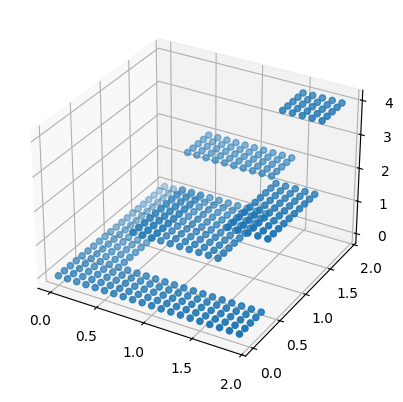

c:\Users\Filip\Documents\mgr-siium\metody_sztucznej_itenligencji\ANFIS.py:89: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   59.66079004870128
Liczba ew:  54082
Liczba it:  50


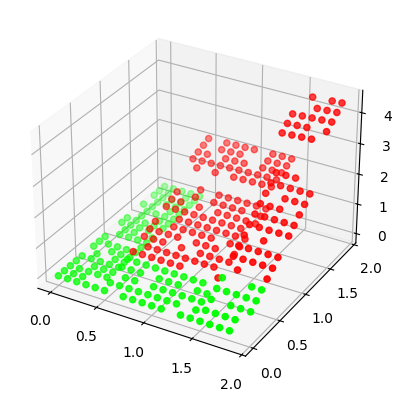

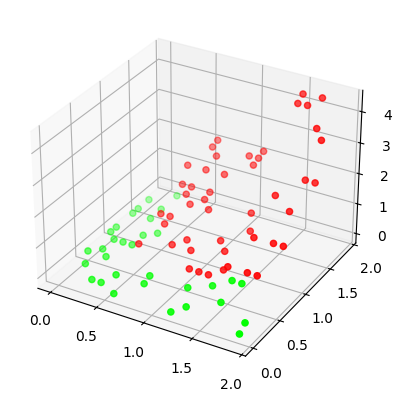

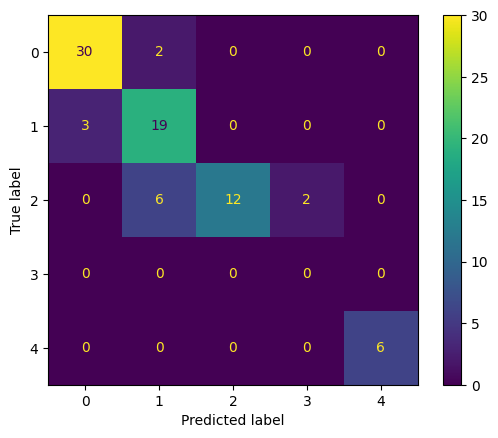

Tabliczka: 3x3


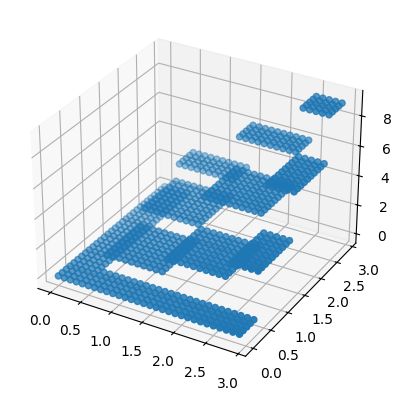

c:\Users\Filip\Documents\mgr-siium\metody_sztucznej_itenligencji\ANFIS.py:89: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   214.87558069864332
Liczba ew:  75993
Liczba it:  50


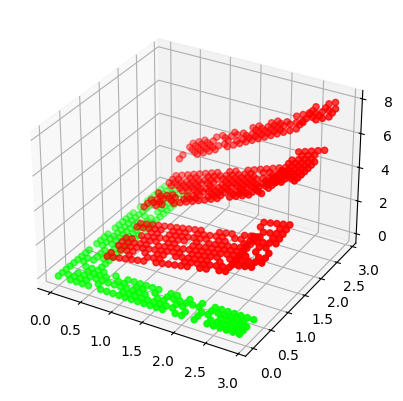

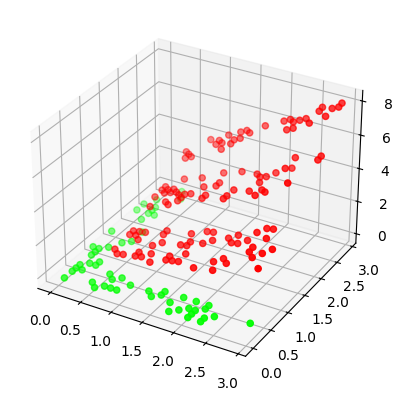

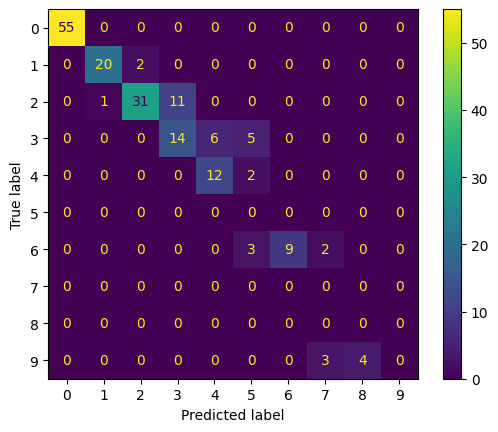

Tabliczka: 4x4


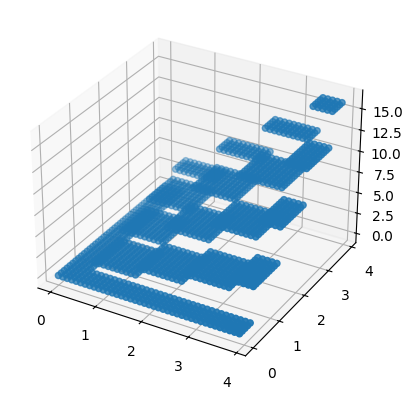

c:\Users\Filip\Documents\mgr-siium\metody_sztucznej_itenligencji\ANFIS.py:89: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   505.6651628417376
Liczba ew:  78391
Liczba it:  50


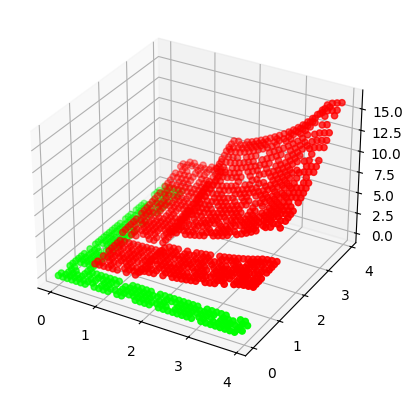

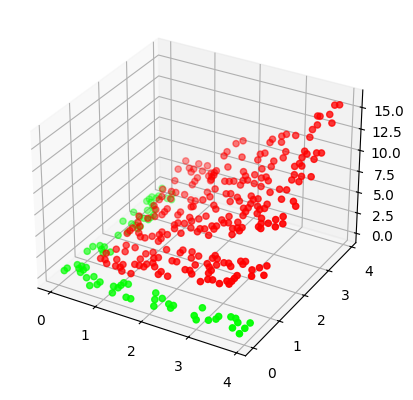

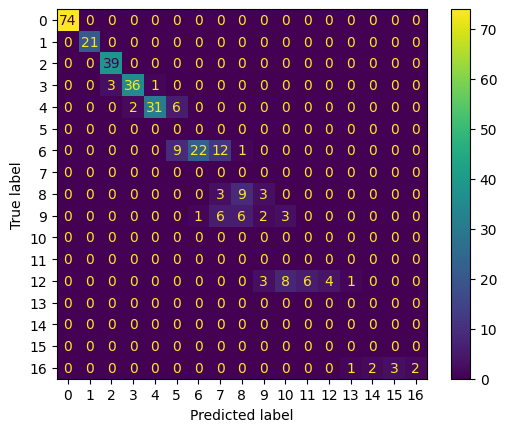

Tabliczka: 5x5


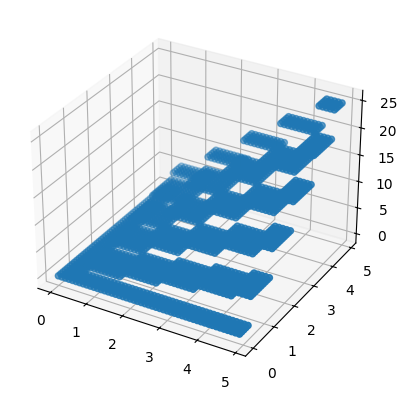

c:\Users\Filip\Documents\mgr-siium\metody_sztucznej_itenligencji\ANFIS.py:89: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   1432.1684056262627
Liczba ew:  80071
Liczba it:  50


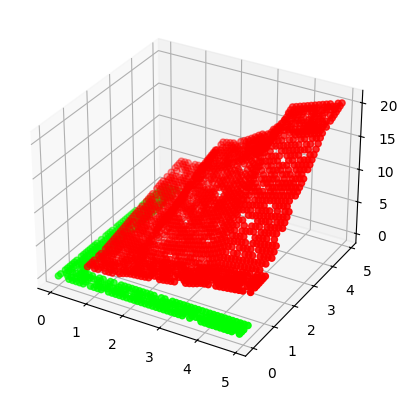

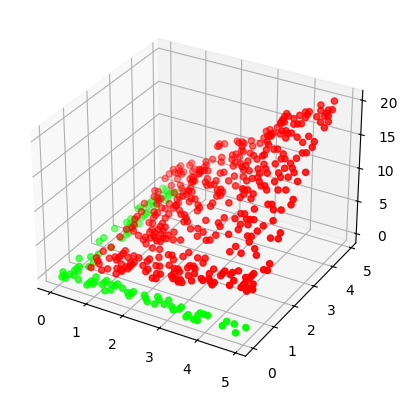

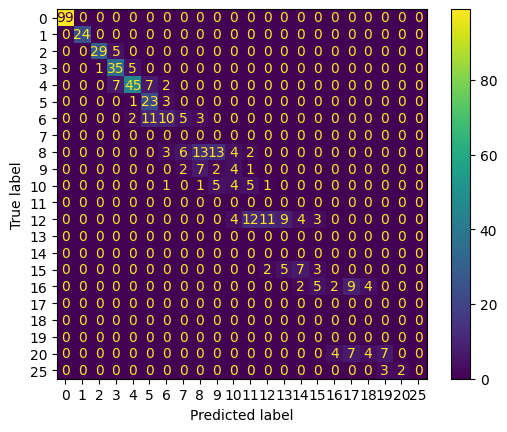

Tabliczka: 6x6


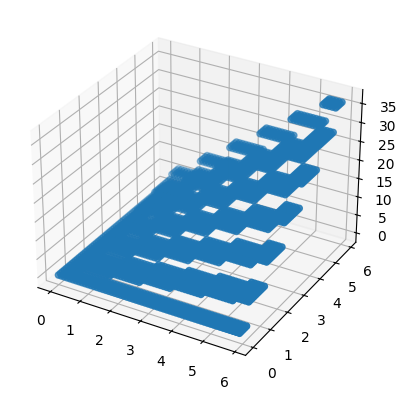

c:\Users\Filip\Documents\mgr-siium\metody_sztucznej_itenligencji\ANFIS.py:89: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   3242.3796105438128
Liczba ew:  94581
Liczba it:  50


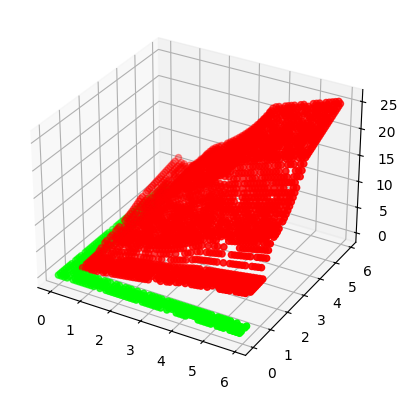

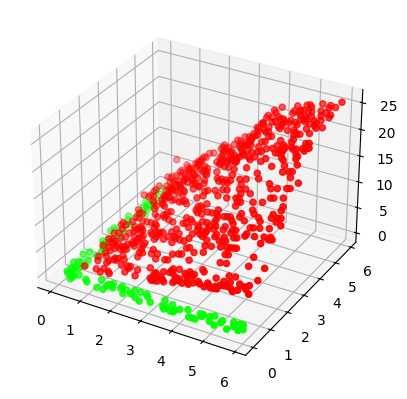

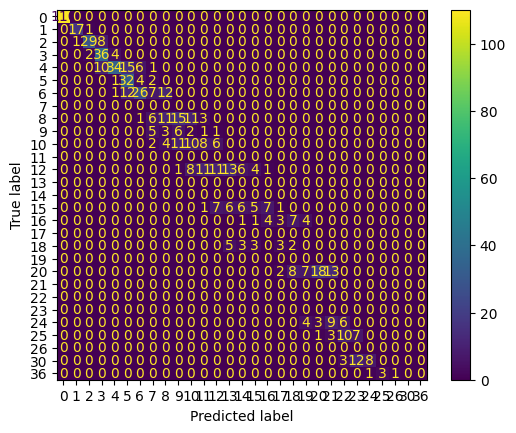

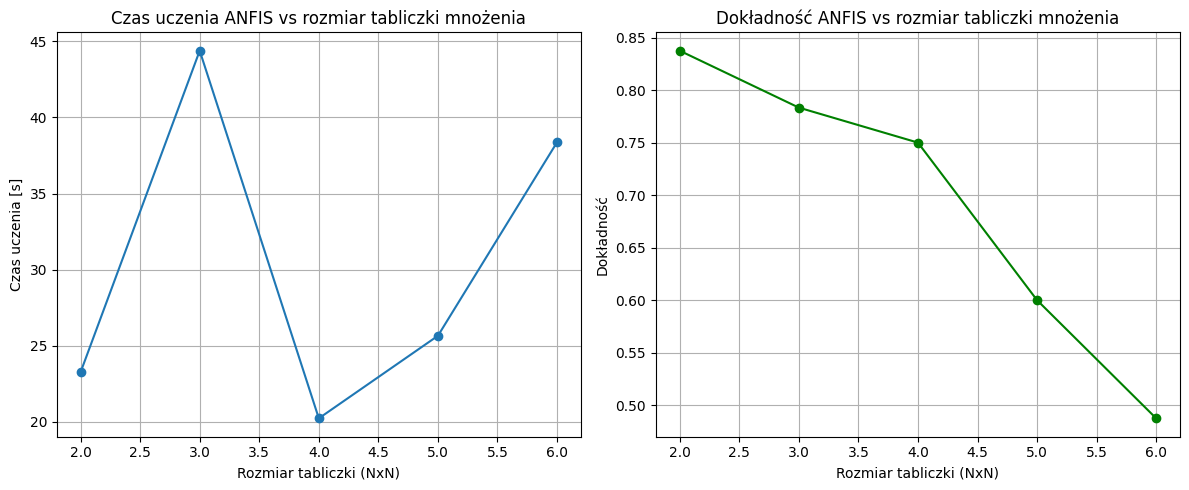

In [65]:
from sklearn.metrics import accuracy_score

sizes = [2, 3, 4, 5, 6]
times = []
accuracies = []

def custom_round(val):
    return int(val + 0.5)

for size in sizes:
    print(f"Tabliczka: {size}x{size}")

    x = np.arange(0, size, 0.1)
    x,y = np.meshgrid(x, x)

    dataX = x.flatten()
    dataY = y.flatten()
    dataXY = np.column_stack((dataX,dataY))   

    data_labels = [custom_round(a) * custom_round(b) for a, b in dataXY]

    # for x in range(len(dataXY)):
    #     print(x, dataXY[x], data_labels[x])

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(dataX, dataY, data_labels)
    plt.show()

    # varX = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "XAxis", ["L","H"]) 
    # varY = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "YAxis", ["L","H"])

    mf1 = [[-0.5, 0.25, 0.25, 0.25], [0.5, 0.25, 0.1, 0.1]]
    varX = FuzzyInputVariable_List_Trapezoids(mf1, "XAxis", ["L","H"])
    varY = FuzzyInputVariable_List_Trapezoids(mf1, "YAxis", ["L","H"])

    X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=25)

    fis = ANFIS([varX, varY], X_train.T, y_train)

    start = time.time()
    fis.train(True, True, False, True, n_iter=50)
    end = time.time()
    times.append(end-start)
    fis.training_data = X_train.T
    fis.expected_labels = y_train
    fis.show_results()

    fis.training_data = X_test.T
    fis.expected_labels = y_test
    fis.show_results()

    y_pred = fis.anfis_estimate_labels(fis.premises,fis.op,fis.tsk)
    y_pred = list(map(round,y_pred.flatten()))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(sizes, times, marker='o')
axs[0].set_xlabel('Rozmiar tabliczki (NxN)')
axs[0].set_ylabel('Czas uczenia [s]')
axs[0].set_title('Czas uczenia ANFIS vs rozmiar tabliczki mnożenia')
axs[0].grid(True)

axs[1].plot(sizes, accuracies, marker='o', color='green')
axs[1].set_xlabel('Rozmiar tabliczki (NxN)')
axs[1].set_ylabel('Dokładność')
axs[1].set_title('Dokładność ANFIS vs rozmiar tabliczki mnożenia')
axs[1].grid(True)

plt.tight_layout()
plt.show()
